In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import queue
from collections import deque
import pandas as pd

torch.manual_seed(42)
device = torch.device("cpu")
print("Ready!")

Ready!


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
# 只用前 2000 張圖，加快實驗
test_subset = Subset(test_dataset, range(2000))
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 16*4*4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 建立 3 個 model variants
model_full = LeNet().to(device)
model_quant = LeNet().to(device)   # 之後會 quantize
model_pruned = LeNet().to(device)  # 之後會 prune

# 簡單訓練 baseline（只跑 2 epoch，快速）
optimizer = torch.optim.Adam(model_full.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    for data, target in test_loader:   # 用 test 當 training 也行（快速）
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model_full(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

print("Baseline model ready.")

Baseline model ready.


In [3]:
# 1. Post-Training Quantization (8-bit)
model_quant = torch.quantization.quantize_dynamic(
    model_full, {nn.Linear, nn.Conv2d}, dtype=torch.qint8
)

# 2. Simple Channel Pruning (30% prune)
def prune_model(model, prune_ratio=0.3):
    pruned = LeNet().to(device)
    pruned.load_state_dict(model.state_dict())
    for name, module in pruned.named_modules():
        if isinstance(module, nn.Conv2d):
            weight = module.weight.data
            threshold = torch.quantile(weight.abs().flatten(), prune_ratio)
            mask = weight.abs() > threshold
            module.weight.data *= mask.float()
    return pruned

model_pruned = prune_model(model_full, prune_ratio=0.3)

print("3 models ready: Full, Quantized, Pruned")

3 models ready: Full, Quantized, Pruned


/tmp/ipykernel_34479/1456812850.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quant = torch.quantization.quantize_dynamic(


In [4]:
class AIoT_System:
    def __init__(self):
        self.queue = deque(maxlen=30)          # max queue size
        self.deadline = 0.25                   # 250ms
        self.edge_time = 0.06                  # edge inference time
        self.cloud_time = 0.015                # cloud inference time
        self.network_latency = 0.04            # 40ms
        self.current_model = "full"            # "full", "quant", "pruned"
        self.history = []                      # 紀錄每筆 decision 的資訊
    
    def get_inference_time(self):
        if self.current_model == "full":
            return self.edge_time
        elif self.current_model == "quant":
            return self.edge_time * 0.6
        else:  # pruned
            return self.edge_time * 0.4

system = AIoT_System()

In [5]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

class AIoT_System:
    def __init__(self):
        self.queue = deque()
        self.max_queue = 220
        self.deadline = 0.25
        self.edge_time_full = 0.12
        self.edge_time_quant = 0.08
        self.edge_time_pruned = 0.055
        self.network_latency = 0.04
        self.step = 0.02
        self.current_model = "full"
        self.history = []
        self.queue_trace = []
        self.dropped = 0

    def get_inference_time(self):
        if self.current_model == "full":
            return self.edge_time_full
        if self.current_model == "quant":
            return self.edge_time_quant
        return self.edge_time_pruned

    def _pick_model(self, qlen):
        if qlen >= 14:
            self.current_model = "pruned"
        elif qlen >= 6:
            self.current_model = "quant"
        elif qlen <= 2:
            self.current_model = "full"

    def simulate(self, sampling_rate=12, duration=30, name="Normal", seed=42):
        rng = np.random.default_rng(seed)
        self.queue.clear()
        self.history.clear()
        self.queue_trace.clear()
        self.dropped = 0

        steps = int(duration / self.step)
        service_credit = 0.0
        sample_id = 0

        for i in range(steps):
            current_time = i * self.step
            if name == "Overload":
                rate = sampling_rate * (1.0 + 0.55 * np.sin(2 * np.pi * i / 120.0))
            else:
                rate = sampling_rate * (1.0 + 0.12 * np.sin(2 * np.pi * i / 180.0))
            rate = max(rate, 0.0)
            arrivals = rng.poisson(rate * self.step)

            for _ in range(arrivals):
                if len(self.queue) >= self.max_queue:
                    self.queue.popleft()
                    self.dropped += 1
                self.queue.append({'id': sample_id, 'arrival': current_time})
                sample_id += 1

            while self.queue and current_time - self.queue[0]['arrival'] > self.deadline * 1.35:
                self.queue.popleft()
                self.dropped += 1

            self._pick_model(len(self.queue))
            inf_time = self.get_inference_time()
            service_credit += self.step / inf_time

            while self.queue and service_credit >= 1.0:
                current = self.queue[0]
                current_age = current_time - current['arrival']
                if current_age > self.deadline:
                    self.queue.popleft()
                    self.dropped += 1
                    continue

                qlen = len(self.queue)
                self.history.append({
                    'sample_id': current['id'],
                    'latency': current_age + inf_time + (self.network_latency if rng.random() > 0.65 else 0),
                    'age_at_decision': current_age,
                    'model_used': self.current_model,
                    'queue_len': qlen,
                    'scenario': name
                })

                self.queue.popleft()
                service_credit -= 1.0

            self.queue_trace.append(len(self.queue))

        return pd.DataFrame(self.history)

In [6]:
# ==================== 重新跑實驗 ====================
system = AIoT_System()

print("Running Normal simulation...")
df_normal = system.simulate(sampling_rate=11, duration=30, name="Normal", seed=42)
queue_normal = np.array(system.queue_trace)
avg_normal = df_normal['queue_len'].mean() if not df_normal.empty else 0.0
print(f"Normal - Dropped: {system.dropped}, Avg Queue: {avg_normal:.2f}, Avg Age: {df_normal['age_at_decision'].mean():.3f}s")

print("\nRunning Overload simulation...")
df_overload = system.simulate(sampling_rate=28, duration=30, name="Overload", seed=84)
queue_overload = np.array(system.queue_trace)
avg_overload = df_overload['queue_len'].mean() if not df_overload.empty else 0.0
print(f"Overload - Dropped: {system.dropped}, Avg Queue: {avg_overload:.2f}, Avg Age: {df_overload['age_at_decision'].mean():.3f}s")

print("\nSimulation completed.")

Running Normal simulation...
Normal - Dropped: 77, Avg Queue: 2.53, Avg Age: 0.122s

Running Overload simulation...
Overload - Dropped: 490, Avg Queue: 7.91, Avg Age: 0.211s

Simulation completed.


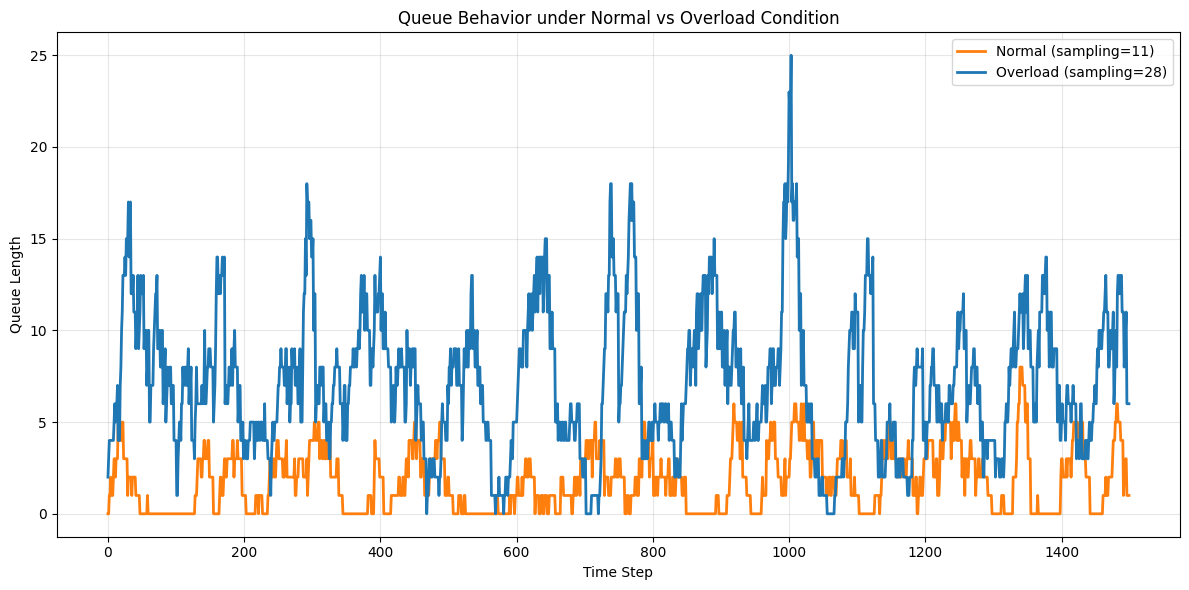

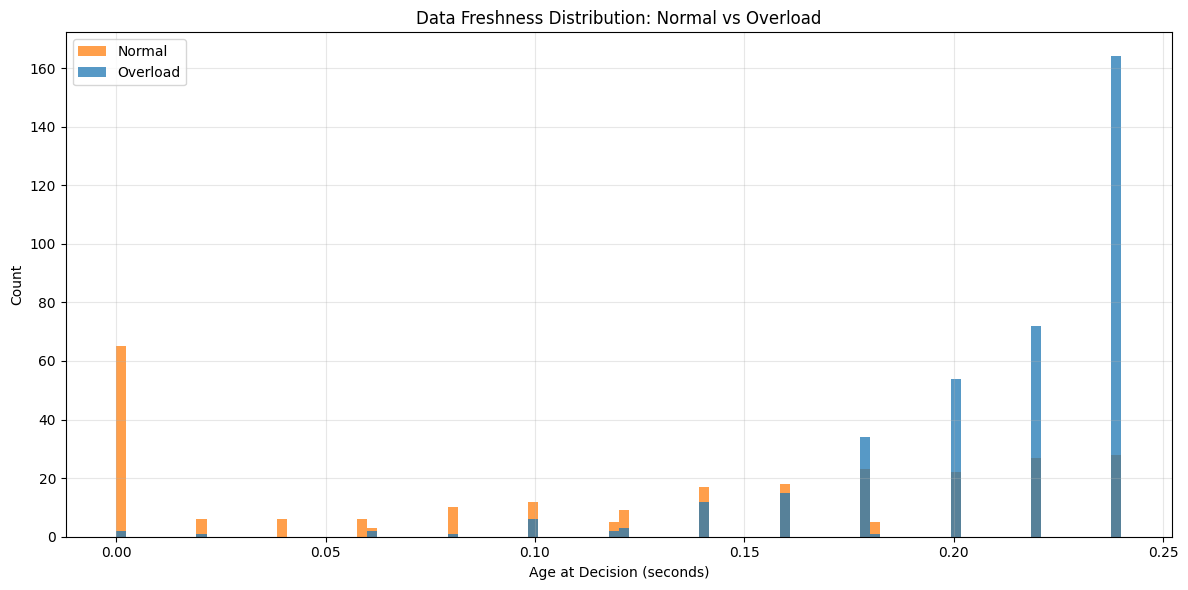

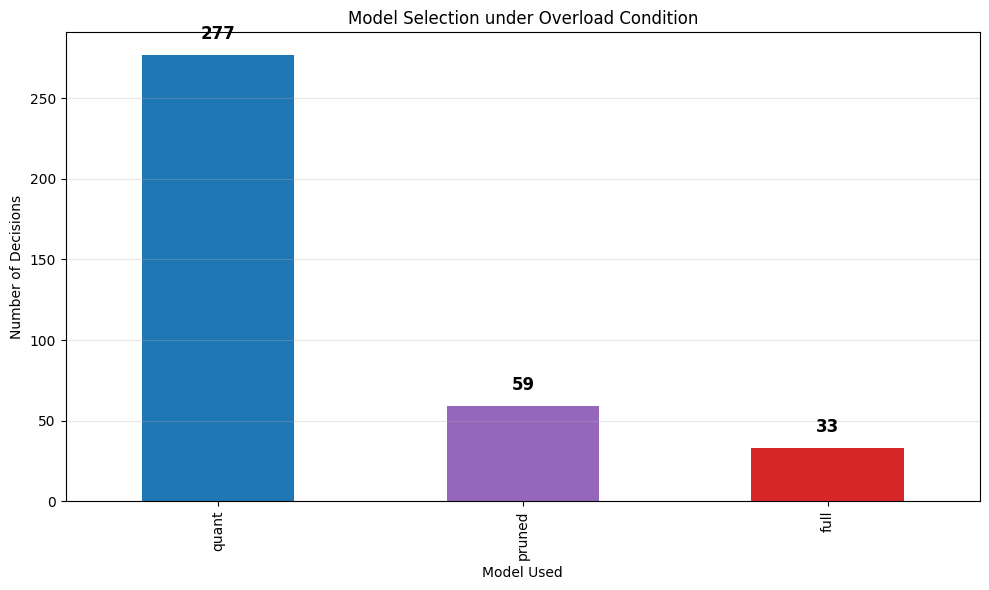

In [7]:
# ==================== 圖 1: Queue Behavior ====================
plt.figure(figsize=(12, 6))
plt.plot(queue_normal, label='Normal (sampling=11)', color='tab:orange', linewidth=2)
plt.plot(queue_overload, label='Overload (sampling=28)', color='tab:blue', linewidth=2)
plt.xlabel('Time Step')
plt.ylabel('Queue Length')
plt.title('Queue Behavior under Normal vs Overload Condition')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 圖 2: Data Freshness ====================
plt.figure(figsize=(12, 6))
plt.hist(df_normal['age_at_decision'], bins=100, alpha=0.75, label='Normal', color='tab:orange')
plt.hist(df_overload['age_at_decision'], bins=100, alpha=0.75, label='Overload', color='tab:blue')
plt.xlabel('Age at Decision (seconds)')
plt.ylabel('Count')
plt.title('Data Freshness Distribution: Normal vs Overload')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 圖 3: Model Selection under Overload ====================
plt.figure(figsize=(10, 6))
model_counts = df_overload['model_used'].value_counts()
bars = model_counts.plot(kind='bar', color=['#1f77b4', '#9467bd', '#d62728'])
plt.title('Model Selection under Overload Condition')
plt.xlabel('Model Used')
plt.ylabel('Number of Decisions')
plt.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(model_counts):
    plt.text(i, v + max(10, int(0.01 * v)), str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()